# Import packages
##### These are the main packages that you will work with:

In [1]:
# %%

import pandas as pd
import numpy as np
import openap
from openap import top
from traffic.core import Traffic, Flight
from traffic.data import aircraft
import matplotlib.pyplot as plt

# Reading a parquet file. 
##### This file contains EHAM fligths for some aircraft types on April 1, 2023, within bounds=(-10, 40, 30, 60) [lon1, lat1, lon2, lat2]
##### here I merged it with aircraft type


In [2]:
# %%

df = pd.read_parquet("data/2023-04-01.parquet")
ac = pd.DataFrame(aircraft.data)[["icao24", "typecode"]]
df = df.merge(ac)
df

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact,serials,hour,typecode
0,2023-04-01 09:00:01+00:00,aa6bc0,56.518094,-7.626057,240.744402,291.301221,0.0,UAL71,False,False,False,2137,10972.8,10736.58,1680339600.768,1680339600.888,"[-1408231114, 1686393261, -1408231801]",2023-04-01 09:00:00+00:00,B772
1,2023-04-01 09:00:02+00:00,aa6bc0,56.518932,-7.630005,240.744402,291.301221,0.0,UAL71,False,False,False,2137,10972.8,10736.58,1680339601.816,1680339601.816,"[-1408231114, -1408231217, 1686393261, -140823...",2023-04-01 09:00:00+00:00,B772
2,2023-04-01 09:00:03+00:00,aa6bc0,56.519724,-7.633696,240.744402,291.301221,0.0,UAL71,False,False,False,2137,10972.8,10736.58,1680339602.932,1680339602.932,"[-1408231114, -1408231217, 1686393261, -140823...",2023-04-01 09:00:00+00:00,B772
3,2023-04-01 09:00:04+00:00,aa6bc0,56.520126,-7.635498,240.744402,291.301221,0.0,UAL71,False,False,False,2137,10972.8,10736.58,1680339603.451,1680339603.602,"[-1408231114, -1408231217, 1686393261, -140823...",2023-04-01 09:00:00+00:00,B772
4,2023-04-01 09:00:05+00:00,aa6bc0,56.521133,-7.640242,240.744402,291.301221,0.0,UAL71,False,False,False,2137,10972.8,10736.58,1680339604.913,1680339604.913,"[-1408231114, -1408231217, 1686393261, -140823...",2023-04-01 09:00:00+00:00,B772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576162,2023-04-01 16:36:12+00:00,486484,51.38237,-2.726985,42.810273,265.865329,-0.32512,KLM91Q,False,False,False,7332,198.12,243.84,1680366971.779,1680366971.838,"[-1408231737, -1408230893, -1408234457]",2023-04-01 16:00:00+00:00,E295
576163,2023-04-01 16:36:13+00:00,486484,51.382358,-2.727509,39.182265,266.235965,-0.65024,KLM91Q,False,False,False,7332,198.12,243.84,1680366972.835,1680366972.835,"[-1408231737, -1408230893, -1408234457]",2023-04-01 16:00:00+00:00,E295
576164,2023-04-01 16:36:14+00:00,486484,51.382324,-2.728098,35.076631,265.794643,-0.65024,KLM91Q,False,False,False,7332,198.12,243.84,1680366973.912,1680366973.944,"[-1408231737, -1408230893, -1408234457]",2023-04-01 16:00:00+00:00,E295
576165,2023-04-01 16:36:15+00:00,486484,51.382312,-2.7285,30.421871,266.121475,-0.65024,KLM91Q,False,False,False,7332,198.12,243.84,1680366974.834,1680366974.942,"[-1408231737, -1408230893, -1408234457]",2023-04-01 16:00:00+00:00,E295


##### Rename some columns and drop geoaltitude to avoid confusion:

In [3]:
# %%

df = df.rename(
    columns={
        "time": "timestamp",
        "lat": "latitude",
        "lon": "longitude",
        "heading": "track",
    }
).drop(columns=["geoaltitude"])
df

,timestamp,icao24,latitude,longitude,velocity,track,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,lastposupdate,lastcontact,serials,hour,typecode
0,2023-04-01 09:00:01+00:00,aa6bc0,56.518094,-7.626057,240.744402,291.301221,0.0,UAL71,False,False,False,2137,10972.8,1680339600.768,1680339600.888,"[-1408231114, 1686393261, -1408231801]",2023-04-01 09:00:00+00:00,B772
1,2023-04-01 09:00:02+00:00,aa6bc0,56.518932,-7.630005,240.744402,291.301221,0.0,UAL71,False,False,False,2137,10972.8,1680339601.816,1680339601.816,"[-1408231114, -1408231217, 1686393261, -140823...",2023-04-01 09:00:00+00:00,B772
2,2023-04-01 09:00:03+00:00,aa6bc0,56.519724,-7.633696,240.744402,291.301221,0.0,UAL71,False,False,False,2137,10972.8,1680339602.932,1680339602.932,"[-1408231114, -1408231217, 1686393261, -140823...",2023-04-01 09:00:00+00:00,B772
3,2023-04-01 09:00:04+00:00,aa6bc0,56.520126,-7.635498,240.744402,291.301221,0.0,UAL71,False,False,False,2137,10972.8,1680339603.451,1680339603.602,"[-1408231114, -1408231217, 1686393261, -140823...",2023-04-01 09:00:00+00:00,B772
4,2023-04-01 09:00:05+00:00,aa6bc0,56.521133,-7.640242,240.744402,291.301221,0.0,UAL71,False,False,False,2137,10972.8,1680339604.913,1680339604.913,"[-1408231114, -1408231217, 1686393261, -140823...",2023-04-01 09:00:00+00:00,B772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576162,2023-04-01 16:36:12+00:00,486484,51.38237,-2.726985,42.810273,265.865329,-0.32512,KLM91Q,False,False,False,7332,198.12,1680366971.779,1680366971.838,"[-1408231737, -1408230893, -1408234457]",2023-04-01 16:00:00+00:00,E295
576163,2023-04-01 16:36:13+00:00,486484,51.382358,-2.727509,39.182265,266.235965,-0.65024,KLM91Q,False,False,False,7332,198.12,1680366972.835,1680366972.835,"[-1408231737, -1408230893, -1408234457]",2023-04-01 16:00:00+00:00,E295
576164,2023-04-01 16:36:14+00:00,486484,51.382324,-2.728098,35.076631,265.794643,-0.65024,KLM91Q,False,False,False,7332,198.12,1680366973.912,1680366973.944,"[-1408231737, -1408230893, -1408234457]",2023-04-01 16:00:00+00:00,E295
576165,2023-04-01 16:36:15+00:00,486484,51.382312,-2.7285,30.421871,266.121475,-0.65024,KLM91Q,False,False,False,7332,198.12,1680366974.834,1680366974.942,"[-1408231737, -1408230893, -1408234457]",2023-04-01 16:00:00+00:00,E295


##### You can check the unit sof this data here: https://opensky-network.org/data/historical-flight-data
##### Add new columns with converted units:

In [4]:
# %%

df = df.assign(
    altitude=df.baroaltitude / openap.aero.ft,
    vertical_rate=df.vertrate / openap.aero.ft * 60,
    groundspeed=df.velocity / openap.aero.kts,
)
df

,timestamp,icao24,latitude,longitude,velocity,track,vertrate,callsign,onground,alert,...,squawk,baroaltitude,lastposupdate,lastcontact,serials,hour,typecode,altitude,vertical_rate,groundspeed
0,2023-04-01 09:00:01+00:00,aa6bc0,56.518094,-7.626057,240.744402,291.301221,0.0,UAL71,False,False,...,2137,10972.8,1680339600.768,1680339600.888,"[-1408231114, 1686393261, -1408231801]",2023-04-01 09:00:00+00:00,B772,36000.0,0.0,467.970085
1,2023-04-01 09:00:02+00:00,aa6bc0,56.518932,-7.630005,240.744402,291.301221,0.0,UAL71,False,False,...,2137,10972.8,1680339601.816,1680339601.816,"[-1408231114, -1408231217, 1686393261, -140823...",2023-04-01 09:00:00+00:00,B772,36000.0,0.0,467.970085
2,2023-04-01 09:00:03+00:00,aa6bc0,56.519724,-7.633696,240.744402,291.301221,0.0,UAL71,False,False,...,2137,10972.8,1680339602.932,1680339602.932,"[-1408231114, -1408231217, 1686393261, -140823...",2023-04-01 09:00:00+00:00,B772,36000.0,0.0,467.970085
3,2023-04-01 09:00:04+00:00,aa6bc0,56.520126,-7.635498,240.744402,291.301221,0.0,UAL71,False,False,...,2137,10972.8,1680339603.451,1680339603.602,"[-1408231114, -1408231217, 1686393261, -140823...",2023-04-01 09:00:00+00:00,B772,36000.0,0.0,467.970085
4,2023-04-01 09:00:05+00:00,aa6bc0,56.521133,-7.640242,240.744402,291.301221,0.0,UAL71,False,False,...,2137,10972.8,1680339604.913,1680339604.913,"[-1408231114, -1408231217, 1686393261, -140823...",2023-04-01 09:00:00+00:00,B772,36000.0,0.0,467.970085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576162,2023-04-01 16:36:12+00:00,486484,51.38237,-2.726985,42.810273,265.865329,-0.32512,KLM91Q,False,False,...,7332,198.12,1680366971.779,1680366971.838,"[-1408231737, -1408230893, -1408234457]",2023-04-01 16:00:00+00:00,E295,650.0,-64.0,83.216585
576163,2023-04-01 16:36:13+00:00,486484,51.382358,-2.727509,39.182265,266.235965,-0.65024,KLM91Q,False,False,...,7332,198.12,1680366972.835,1680366972.835,"[-1408231737, -1408230893, -1408234457]",2023-04-01 16:00:00+00:00,E295,650.0,-128.0,76.164296
576164,2023-04-01 16:36:14+00:00,486484,51.382324,-2.728098,35.076631,265.794643,-0.65024,KLM91Q,False,False,...,7332,198.12,1680366973.912,1680366973.944,"[-1408231737, -1408230893, -1408234457]",2023-04-01 16:00:00+00:00,E295,650.0,-128.0,68.183576
576165,2023-04-01 16:36:15+00:00,486484,51.382312,-2.7285,30.421871,266.121475,-0.65024,KLM91Q,False,False,...,7332,198.12,1680366974.834,1680366974.942,"[-1408231737, -1408230893, -1408234457]",2023-04-01 16:00:00+00:00,E295,650.0,-128.0,59.135438


##### For some reason Traffic library didn't plot the fligths with the original datatypes. For this reason I added this step: 

In [5]:
# %%

df[["onground", "alert", "spi"]] = df[["onground", "alert", "spi"]].astype(bool)
df[["timestamp", "hour"]] = df[["timestamp", "hour"]].astype("datetime64[ns, UTC]")
df[["callsign", "squawk"]] = df[["callsign", "squawk"]].astype(object)
df.dtypes

timestamp        datetime64[ns, UTC]
icao24                        object
latitude             double[pyarrow]
longitude            double[pyarrow]
velocity             double[pyarrow]
track                double[pyarrow]
vertrate             double[pyarrow]
callsign                      object
onground                        bool
alert                           bool
spi                             bool
squawk                        object
baroaltitude         double[pyarrow]
lastposupdate        double[pyarrow]
lastcontact          double[pyarrow]
serials                       object
hour             datetime64[ns, UTC]
typecode                      object
altitude             double[pyarrow]
vertical_rate        double[pyarrow]
groundspeed          double[pyarrow]
dtype: object

##### One of the ways to filter out A320 fligths

In [6]:
# %%
df["typecode"] = df.typecode.apply(lambda x: x.lower())
df_a320 = df.query("typecode=='a320'")
df_a320

,timestamp,icao24,latitude,longitude,velocity,track,vertrate,callsign,onground,alert,...,squawk,baroaltitude,lastposupdate,lastcontact,serials,hour,typecode,altitude,vertical_rate,groundspeed
12006,2023-04-01 09:00:01+00:00,440050,51.461032,9.399872,227.117558,297.667873,-0.32512,AUA379,False,False,...,1000,10980.42,1680339598.794,1680339600.985,"[-1408232485, 813747574, -1408237567, -1408231...",2023-04-01 09:00:00+00:00,a320,36025.0,-64.0,441.481596
12007,2023-04-01 09:00:02+00:00,440050,51.46376,9.391529,227.117558,297.667873,-0.32512,AUA379,False,False,...,1000,10980.42,1680339601.735,1680339601.996,"[-1408232485, 813747574, -1408237567, -1408231...",2023-04-01 09:00:00+00:00,a320,36025.0,-64.0,441.481596
12008,2023-04-01 09:00:03+00:00,440050,51.464813,9.388337,227.117558,297.667873,-0.32512,AUA379,False,False,...,1000,10980.42,1680339602.775,1680339602.986,"[-1408230772, -1408231534, -1408236346, -14082...",2023-04-01 09:00:00+00:00,a320,36025.0,-64.0,441.481596
12009,2023-04-01 09:00:04+00:00,440050,51.465827,9.385147,227.117558,297.667873,-0.32512,AUA379,False,False,...,1000,10980.42,1680339603.894,1680339604.0,"[-1408230772, -1408231534, -1408236346, -14082...",2023-04-01 09:00:00+00:00,a320,36025.0,-64.0,441.481596
12010,2023-04-01 09:00:05+00:00,440050,51.466758,9.382248,226.879136,297.552812,-0.32512,AUA379,False,False,...,1000,10980.42,1680339604.913,1680339604.999,"[-1408230772, -1408231534, -1408236346, -14082...",2023-04-01 09:00:00+00:00,a320,36025.0,-64.0,441.01814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
554580,2023-04-01 18:59:55+00:00,440141,51.560715,-1.44923,177.888308,280.497511,-10.40384,EJU43NJ,False,False,...,7335,5524.5,1680375594.576,1680375594.969,"[-1408236086, 1408235638, -1408233531, -140823...",2023-04-01 18:00:00+00:00,a320,18125.0,-2048.0,345.787507
554581,2023-04-01 18:59:56+00:00,440141,51.560979,-1.451645,177.888308,280.497511,-10.40384,EJU43NJ,False,False,...,7335,5516.88,1680375595.525,1680375595.998,"[-1408236086, 1408235638, -1408233531, -140823...",2023-04-01 18:00:00+00:00,a320,18100.0,-2048.0,345.787507
554582,2023-04-01 18:59:57+00:00,440141,51.56131,-1.454278,177.888308,280.497511,-10.40384,EJU43NJ,False,False,...,7335,5501.64,1680375596.579,1680375597.0,"[-1408236086, 1408235638, -1408233531, -140823...",2023-04-01 18:00:00+00:00,a320,18050.0,-2048.0,345.787507
554583,2023-04-01 18:59:58+00:00,440141,51.561584,-1.456802,177.888308,280.497511,-10.40384,EJU43NJ,False,False,...,7335,5494.02,1680375597.605,1680375597.997,"[-1408236086, 1408235638, -1408233531, -140823...",2023-04-01 18:00:00+00:00,a320,18025.0,-2048.0,345.787507


# Using Traffic
##### Traffic library helps to break the df into flights.
##### As you can see, here we have 111 fligths. "count" represents the amount of data points we have for this particular flight.

In [7]:
# %%

t = Traffic(df)
t

,,count
icao24,callsign,
484416,KLM880,9720
45caba,TRA88P,9649
48436e,KLM876,8988
484369,KLM875,8923
4520ce,LZB461,8897
48436c,KLM887,8787
48436f,KLM897,8755
484370,KLM845,8652
4843f3,KLM895,8625


##### Consider a320 flights only:

In [8]:
# %%

t = Traffic(df_a320)
t

,,count
icao24,callsign,
45caba,TRA88P,9649
4520ce,LZB461,8897
345398,VLG6HC,8340
4520ce,LZB462,8239
4951ca,TAP668,7867
344455,IBS37MU,7566
343385,IBS3723,7433
45caba,TRA5807,7381
344455,IBS3725,7283


##### For instance, lets check the flight with icao24 = '45caba' 

##### It says that there are several callsigns associated with that icao24

Several callsigns for one flight, consider splitting
Several callsigns for one flight, consider splitting
Several callsigns for one flight, consider splitting
Several callsigns for one flight, consider splitting


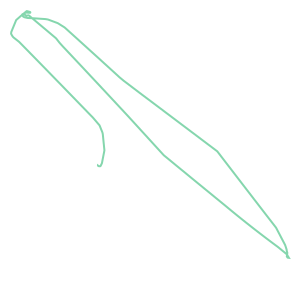

In [9]:
# %%

flight = t["45caba"]
flight

##### If we choose a fligth with a certain callsign (i.e "TRA88P"), we avoid this:

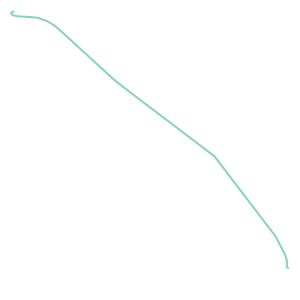

In [10]:
# %%

flight = t["TRA88P"]
flight

##### to access the dataframe of this flight:

In [11]:
flight.data

,timestamp,icao24,latitude,longitude,velocity,track,vertrate,callsign,onground,alert,...,squawk,baroaltitude,lastposupdate,lastcontact,serials,hour,typecode,altitude,vertical_rate,groundspeed
63715,2023-04-01 16:00:01+00:00,45caba,52.134293,4.612274,104.060208,316.201833,0.0,TRA88P,False,False,...,1751,708.66,1680364800.713,1680364800.985,"[-1408230646, -1408234794, 1163147025, -140823...",2023-04-01 16:00:00+00:00,a320,2325.0,0.0,202.277038
63716,2023-04-01 16:00:02+00:00,45caba,52.135061,4.610962,103.332836,316.210294,0.0,TRA88P,False,False,...,1751,701.04,1680364801.854,1680364801.988,"[-1408234794, 1163147025, 1433788987, -1408234...",2023-04-01 16:00:00+00:00,a320,2300.0,0.0,200.863137
63717,2023-04-01 16:00:03+00:00,45caba,52.13548,4.610334,103.320029,315.806929,-0.32512,TRA88P,False,False,...,1751,701.04,1680364802.745,1680364802.991,"[-1408234794, 1163147025, 1433788987, -1408234...",2023-04-01 16:00:00+00:00,a320,2300.0,-64.0,200.838243
63718,2023-04-01 16:00:04+00:00,45caba,52.136169,4.609299,102.977503,316.416921,-0.32512,TRA88P,False,False,...,1751,701.04,1680364803.587,1680364803.959,"[-1408234794, 1163147025, 1433788987, 91032, -...",2023-04-01 16:00:00+00:00,a320,2300.0,-64.0,200.172426
63719,2023-04-01 16:00:05+00:00,45caba,52.13683,4.608294,102.605466,316.218875,-0.32512,TRA88P,False,False,...,1751,701.04,1680364804.588,1680364804.952,"[-1408234794, 1163147025, 1433788987, 91032, -...",2023-04-01 16:00:00+00:00,a320,2300.0,-64.0,199.449242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431206,2023-04-01 13:59:55+00:00,45caba,43.783768,20.898551,218.626595,327.394384,0.0,TRA88P,False,False,...,<NA>,10957.56,1680357594.827,1680357594.827,[-1408232790],2023-04-01 13:00:00+00:00,a320,35950.0,0.0,424.97647
431207,2023-04-01 13:59:56+00:00,45caba,43.785406,20.897108,218.626595,327.394384,0.0,TRA88P,False,False,...,<NA>,10957.56,1680357595.753,1680357595.979,[-1408232790],2023-04-01 13:00:00+00:00,a320,35950.0,0.0,424.97647
431208,2023-04-01 13:59:57+00:00,45caba,43.786743,20.895932,218.626595,327.394384,0.0,TRA88P,False,False,...,<NA>,10957.56,1680357596.853,1680357596.853,[-1408232790],2023-04-01 13:00:00+00:00,a320,35950.0,0.0,424.97647
431209,2023-04-01 13:59:58+00:00,45caba,43.786743,20.895932,218.626595,327.394384,0.0,TRA88P,False,False,...,<NA>,10957.56,1680357596.853,1680357597.722,[-1408232790],2023-04-01 13:00:00+00:00,a320,35950.0,0.0,424.97647


# Using OpenAP
### The following cells are copied from https://openap.dev/fuel_emission.html
### Please check that page for details.

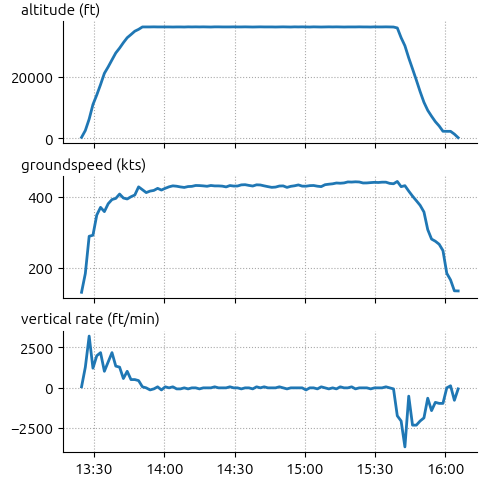

In [12]:
# %%

df = flight.filter().resample(100).data
df = df.assign(d_ts=df.timestamp.diff().astype("timedelta64[s]").bfill().astype(int))
df = df.assign(ts=df.d_ts.cumsum())

from matplotlib import dates

import matplotlib

matplotlib.rc("font", size=11)
matplotlib.rc("font", family="Ubuntu")
matplotlib.rc("lines", linewidth=2, markersize=8)
matplotlib.rc("grid", color="darkgray", linestyle=":")


def format_ax(ax):
    ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.yaxis.set_label_coords(-0.1, 1.03)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha("left")
    ax.grid()


fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(5, 5), sharex=True)

ax1.plot(df.timestamp, df.altitude)
ax2.plot(df.timestamp, df.groundspeed)
ax3.plot(df.timestamp, df.vertical_rate)

ax1.set_ylabel("altitude (ft)")
ax2.set_ylabel("groundspeed (kts)")
ax3.set_ylabel("vertical rate (ft/min)")

for ax in (ax1, ax2, ax3):
    format_ax(ax)

plt.tight_layout()
plt.show()

In [13]:
# %%

mass_takeoff_assumed = 66300  # kg

fuelflow = openap.FuelFlow("A319")
mass_current = mass_takeoff_assumed

fuelflow_every_step = []
fuel_every_step = []

for i, row in df.iterrows():
    ff = fuelflow.enroute(
        mass=mass_current,
        tas=row.groundspeed,
        alt=row.altitude,
        vs=row.vertical_rate,
    )
    fuel = ff * row.d_ts
    fuelflow_every_step.append(ff)
    fuel_every_step.append(ff * row.d_ts)
    mass_current = mass_current - fuel

df = df.assign(fuel_flow=fuelflow_every_step, fuel=fuel_every_step)

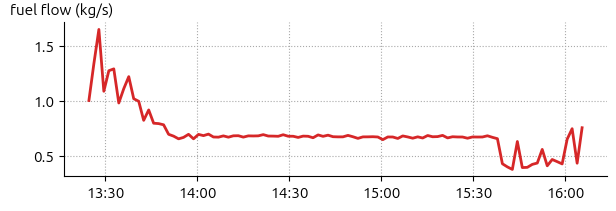

In [14]:
# %%

plt.figure(figsize=(7, 2))
plt.plot(df.timestamp, df.fuel_flow, color="tab:red")
plt.ylabel("fuel flow (kg/s)")
format_ax(plt.gca())
plt.show()

In [15]:
# %%

emission = openap.Emission(ac="A319")

df = df.assign(
    co2_flow=lambda d: emission.co2(d.fuel_flow),
    h2o_flow=lambda d: emission.h2o(d.fuel_flow),
    soot_flow=lambda d: emission.soot(d.fuel_flow),
    sox_flow=lambda d: emission.sox(d.fuel_flow),
    nox_flow=lambda d: emission.nox(d.fuel_flow, tas=d.groundspeed, alt=d.altitude),
    co_flow=lambda d: emission.co(d.fuel_flow, tas=d.groundspeed, alt=d.altitude),
    hc_flow=lambda d: emission.hc(d.fuel_flow, tas=d.groundspeed, alt=d.altitude),
)

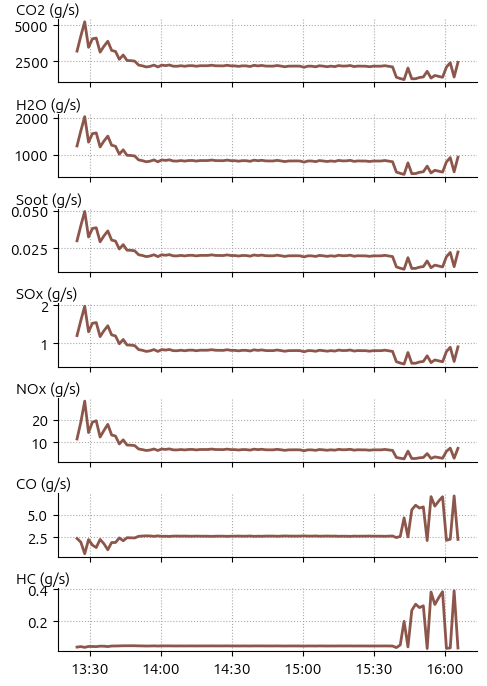

In [16]:
# %%

fig, axes = plt.subplots(7, 1, figsize=(5, 7), sharex=True)

axes = axes.flatten()

labels = dict(
    co2_flow="CO2 (g/s)",
    h2o_flow="H2O (g/s)",
    soot_flow="Soot (g/s)",
    sox_flow="SOx (g/s)",
    nox_flow="NOx (g/s)",
    co_flow="CO (g/s)",
    hc_flow="HC (g/s)",
)

for i, (k, v) in enumerate(labels.items()):
    axes[i].plot(df.timestamp, df[k], color="tab:brown")
    axes[i].set_ylabel(v)
    format_ax(axes[i])


plt.tight_layout()
plt.show()

In [17]:
# %%

df = df.eval(
    """
    co2 = co2_flow * d_ts / 1000
    h2o = h2o_flow * d_ts / 1000
    soot = soot_flow * d_ts / 1000
    sox = sox_flow * d_ts / 1000
    nox = nox_flow * d_ts / 1000
    co = co_flow * d_ts / 1000
    hc = hc_flow * d_ts / 1000
    """
)

In [18]:
# %%

df[["timestamp", "fuel", "co2", "h2o", "soot", "sox", "nox", "co", "hc"]].round(4)

,timestamp,fuel,co2,h2o,soot,sox,nox,co,hc
0,2023-04-01 13:24:40+00:00,97.2605,307.3431,119.6304,0.0029,0.1167,1.1127,0.2254,0.0040
1,2023-04-01 13:26:17+00:00,129.5513,409.3820,159.3480,0.0039,0.1555,1.8346,0.1858,0.0043
2,2023-04-01 13:27:55+00:00,161.3754,509.9462,198.4917,0.0048,0.1937,2.7582,0.0607,0.0039
3,2023-04-01 13:29:32+00:00,105.3784,332.9957,129.6154,0.0032,0.1265,1.3859,0.2132,0.0044
4,2023-04-01 13:31:10+00:00,124.7053,394.0686,153.3875,0.0037,0.1496,1.8495,0.1554,0.0044
...,...,...,...,...,...,...,...,...,...
95,2023-04-01 15:59:02+00:00,41.5248,131.2185,51.0756,0.0012,0.0498,0.2885,0.6788,0.0371
96,2023-04-01 16:00:40+00:00,63.8994,201.9221,78.5962,0.0019,0.0767,0.5932,0.2079,0.0032
97,2023-04-01 16:02:17+00:00,72.4752,229.0217,89.1445,0.0022,0.0870,0.7210,0.2176,0.0035
98,2023-04-01 16:03:55+00:00,42.5807,134.5549,52.3742,0.0013,0.0511,0.2932,0.6946,0.0381


In [19]:
# %%

df[["fuel", "co2", "h2o", "soot", "sox", "nox", "co", "hc"]].sum().round(2)

fuel     6896.08
co2     21791.61
h2o      8482.18
soot        0.21
sox         8.28
nox        73.09
co         27.41
hc          0.72
dtype: float64

# Using OpenAP.TOP

##### Let's try to generate the optimal version of this fligth, for this we need max takeoff weight of this aircraft type:

In [28]:
aircraft = openap.prop.aircraft("a320")
m_mtow = aircraft["limits"]["MTOW"]
m_mtow

78000

##### sort the real flight and get the start and end points

In [31]:
flight.data = flight.data.sort_values(by=["timestamp"]).reset_index(drop=True)
start = flight.data.iloc[0, :]
end = flight.data.iloc[-1, :]

##### In the emissions estimation above we used and assumed mass "mass_takeoff_assumed" of 66300 kg. For the optimizer we need a ratio of assumed mass to the maximum takeoff mass

In [32]:
# %%
actype = "A320"
origin = (start.latitude, start.longitude)
destination = (end.latitude, end.longitude)
m0 = mass_takeoff_assumed / m_mtow
optimizer = top.CompleteFlight(actype, origin, destination, m0=m0)
optimizer.setup_dc(nodes=100)

flight1 = optimizer.trajectory(objective="fuel")

flight1 = flight1.assign(
    distance=lambda d: ((d.x - d.x.iloc[0]) / 1000).astype(int),
).drop(["x", "y"], axis=1)
flight1

CasADi - 2024-11-11 14:24:24 WARNING("solver:nlp_g failed: Inf detected for output g, at (row 3, col 0).") [.../casadi/core/oracle_function.cpp:393]


,ts,h,latitude,longitude,altitude,mach,tas,vertical_rate,heading,mass,fuel,distance
0,0.0,457.200000,40.517916,22.980543,1500.0,0.1000,65.81,2500.0,319.48,66300.0,108.092132,0
1,82.0,1501.457338,40.537296,22.963163,4926.0,0.3000,195.05,2000.0,313.10,66255.0,148.314855,-1
2,164.0,2336.863213,40.592926,22.900264,7667.0,0.5000,321.90,2500.0,313.10,66106.0,134.190660,-7
3,247.0,3381.120548,40.684206,22.796748,11093.0,0.6842,434.97,2500.0,313.10,65973.0,136.808930,-17
4,329.0,4425.377884,40.807092,22.656780,14519.0,0.7147,448.52,2500.0,313.10,65840.0,133.122597,-30
...,...,...,...,...,...,...,...,...,...,...,...,...
96,7894.0,4007.674922,51.996490,5.367284,13149.0,0.6136,387.08,-2500.0,313.10,59819.0,36.229656,-1351
97,7976.0,2963.417591,52.083792,5.176179,9722.0,0.5722,365.63,-2500.0,313.10,59782.0,35.194246,-1363
98,8058.0,1919.160266,52.166340,4.994168,6296.0,0.5000,323.50,-2000.0,313.10,59746.0,35.242158,-1375
99,8140.0,1083.754400,52.239576,4.831607,3556.0,0.3000,196.00,-1500.0,319.48,59710.0,31.205791,-1385


### Let's plot and compare real and optimal flights 
##### As you can see here, the real fligth has an outlier:

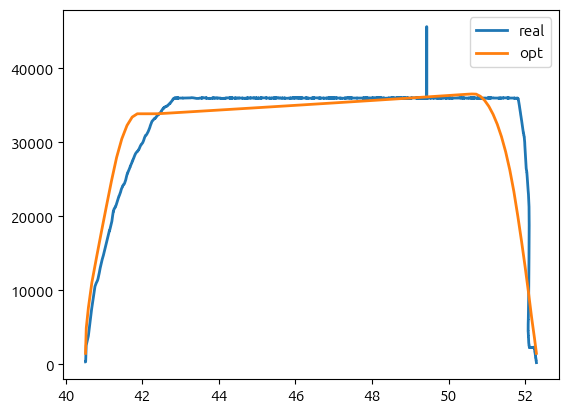

In [34]:
plt.plot(flight.data.latitude, flight.data.altitude, label="real")
plt.plot(flight1.latitude, flight1.altitude, label="opt")
plt.legend()

### To get rid of this outlier we can use in-built function in the Traffic library:

In [35]:
flight = flight.filter()

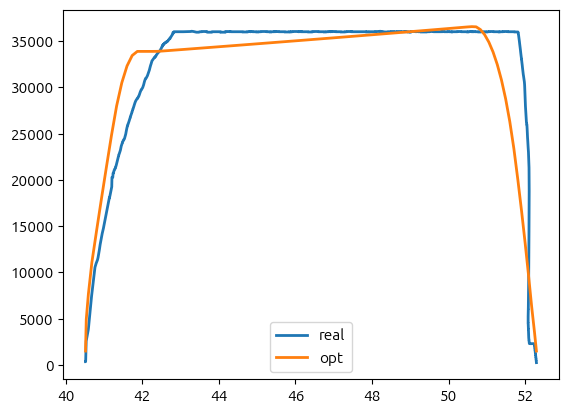

In [36]:
plt.plot(flight.data.latitude, flight.data.altitude, label="real")
plt.plot(flight1.latitude, flight1.altitude, label="opt")
plt.legend()

### Another useful fuction form traffic is "resample()", you can resample by time, and by the number of nodes. Sometimes I do both, first by time to get rid of any discontinuities, and then by number of nodes, to make the dataframe lighter and speed up further calculations.

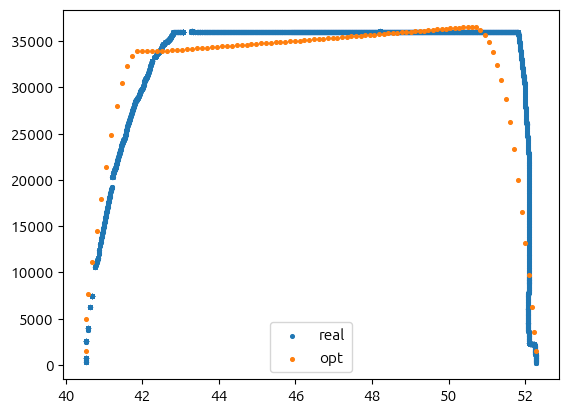

In [37]:
plt.scatter(flight.data.latitude, flight.data.altitude, s=7, label="real")
plt.scatter(flight1.latitude, flight1.altitude, s=7, label="opt")
plt.legend()

In [38]:
flight = flight.resample("50s")

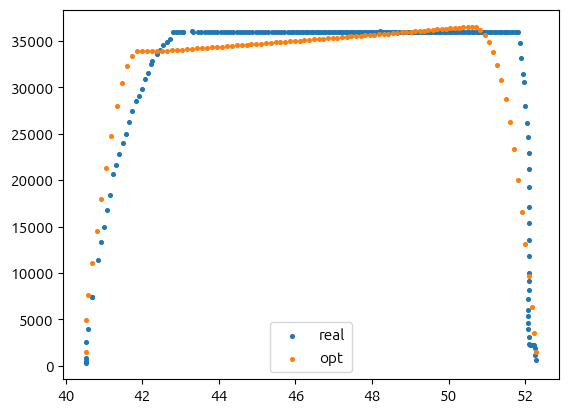

In [39]:
plt.scatter(flight.data.latitude, flight.data.altitude, s=7, label="real")
plt.scatter(flight1.latitude, flight1.altitude, s=7, label="opt")
plt.legend()

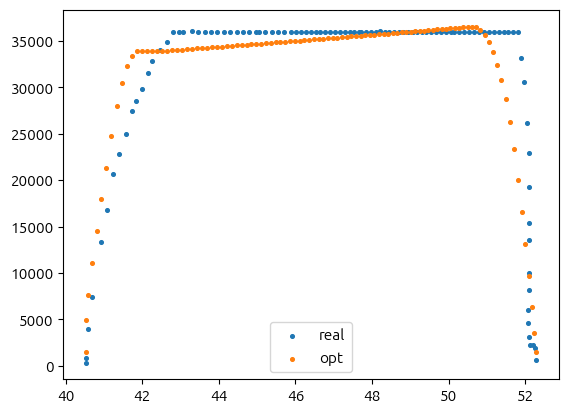

In [40]:
flight = flight.resample(100)
plt.scatter(flight.data.latitude, flight.data.altitude, s=7, label="real")
plt.scatter(flight1.latitude, flight1.altitude, s=7, label="opt")
plt.legend()

### In these examples we used groundspeed as TAS, for more accurate calculations it is necessary to use "fastmeteo" library, to get wind data. and then compute true airspeed by substracting wind speed from groundspeed.